In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from libpysal.weights import Queen
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

In [ ]:
years = [2021.0, 2022.0, 2023.0]
boroughs = ['manhattan', 'brooklyn', 'bronx', 'queens']

borough_year_data = {}
for y in years:
    borough_year_data[y] = {}
    for b in boroughs:
        borough_year_data[y][b] = pd.read_csv(f"..\\Dataset\\NYC_DWT_Analysis\\{y}\\{b}.csv")

nta_gdf = gpd.read_file("..\\Dataset\\NYC_DWT_Analysis\\nynta2020_25d\\nynta2020.shp")
nta_gdf['NTA2020'] = nta_gdf["NTA2020"].astype(str).str.lower()

In [3]:
#NTA aggregation, just as before
nta_data = {}
for y in years:
    nta_data[y] = {}
    for b in boroughs:
        df = borough_year_data[y][b].copy()

        df["has_violation"] = (df["Violation_Code"] != '0').astype(int)
        df["is_audit"] = (df["Activity_Type"] == "nyc health department audit").astype(int)

        agg = df.groupby('NTA_Code').agg(   inspection_count = ("BIN", "count"),
                                            violation_count = ("has_violation", "sum"),
                                            total_dwt = ('Number of DWT', "sum"),
                                            audit_count = ("is_audit", "sum"), ).reset_index()

        agg["violation_rate"] = agg["violation_count"]/agg["inspection_count"]
        agg["avg_dwt"]        = agg["total_dwt"]/agg["inspection_count"]
        agg["audit_fraction"] = agg["audit_count"]/agg["inspection_count"]

        nta_data[y][b] = agg.drop(columns=["violation_count", "total_dwt", "audit_count"])

In [4]:
NTA_Prefix = {'bronx': 'bx', 'queens': 'qn', 'brooklyn': 'bk', 'manhattan': 'mn'}

geo_data = {}
for y in years:
    geo_data[y] = {}
    for b in boroughs:
        prefix = NTA_Prefix[b]
        borough_shape = nta_gdf[nta_gdf["NTA2020"].str.startswith(prefix)].copy()
        merged = borough_shape.merge(nta_data[y][b], left_on="NTA2020", right_on="NTA_Code", how="left")
        for col in ["inspection_count", "violation_rate", "avg_dwt", "audit_fraction"]:
            merged[col] = merged[col].fillna(0)
        geo_data[y][b] = merged.reset_index(drop=True)

In [5]:
#Q statistics with boroughs as strata
q_results = []
for y in years:
    for var in ["inspection_count", "violation_rate"]:
        all_vals = []
        strata   = []
        for b in boroughs:
            vals = nta_data[y][b][var].values
            all_vals.extend(vals)
            strata.extend([b] * len(vals))

        all_vals = np.array(all_vals)
        N = len(all_vals)
        sigma2 = np.var(all_vals)

        intra = 0
        for b in boroughs:
            b_vals   = nta_data[y][b][var].values
            N_h      = len(b_vals)
            sigma2_h = np.var(b_vals)
            intra   += N_h * sigma2_h

        q = 1 - (intra / (N * sigma2)) if sigma2 > 0 else 0

        q_results.append({"year": int(y), "variable": var, "q_statistic": round(q, 4), "N": N, "global_variance": round(sigma2, 4)})

q_df = pd.DataFrame(q_results)

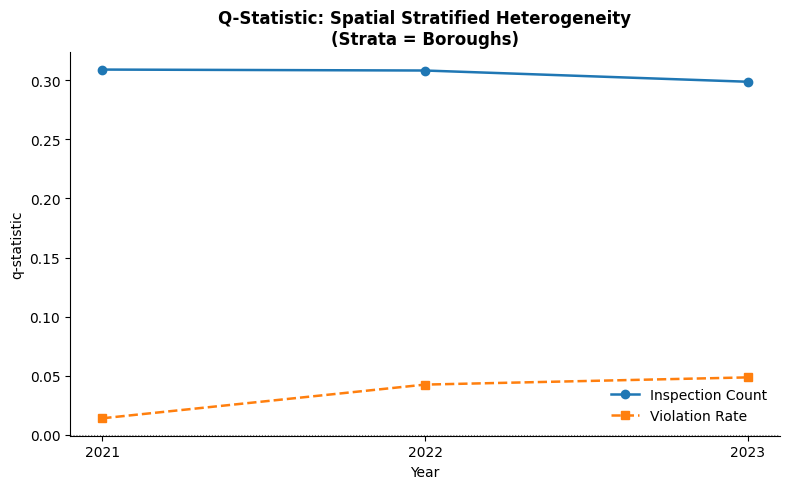

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for var, style in [("inspection_count", "o-"), ("violation_rate", "s--")]:
    subset = q_df[q_df["variable"] == var]
    ax.plot(subset["year"], subset["q_statistic"], style, label=var.replace("_", " ").title(), linewidth=1.8)

ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
ax.set_title("Q-Statistic: Spatial Stratified Heterogeneity\n(Strata = Boroughs)", fontsize=12, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("q-statistic")
ax.set_xticks([int(y) for y in years])
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()